In [63]:
#Import important Libraries

import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error
from sklearn.cluster import KMeans

In [8]:
#Load the Dataset
data=pd.read_csv('/kaggle/input/datasets/ganusha/customer-satisfaction/customer_support_tickets.csv')

In [9]:
#Display the first few rows of the dataset
print(data.head())

   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

In [10]:
print(data.columns)

Index(['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age',
       'Customer Gender', 'Product Purchased', 'Date of Purchase',
       'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status',
       'Resolution', 'Ticket Priority', 'Ticket Channel',
       'First Response Time', 'Time to Resolution',
       'Customer Satisfaction Rating'],
      dtype='object')


In [11]:
#Perform intial exploratory data analysis(EDA)
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8469 entries, 0 to 8468
Data columns (total 17 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticket ID                     8469 non-null   int64  
 1   Customer Name                 8469 non-null   object 
 2   Customer Email                8469 non-null   object 
 3   Customer Age                  8469 non-null   int64  
 4   Customer Gender               8469 non-null   object 
 5   Product Purchased             8469 non-null   object 
 6   Date of Purchase              8469 non-null   object 
 7   Ticket Type                   8469 non-null   object 
 8   Ticket Subject                8469 non-null   object 
 9   Ticket Description            8469 non-null   object 
 10  Ticket Status                 8469 non-null   object 
 11  Resolution                    2769 non-null   object 
 12  Ticket Priority               8469 non-null   object 
 13  Tic

**Analyse Customer support ticket trends**


In [12]:
#Identify Common issues
common_issues= data['Ticket Subject'].value_counts().head(10)
print(common_issues)

Ticket Subject
Refund request           576
Software bug             574
Product compatibility    567
Delivery problem         561
Hardware issue           547
Battery life             542
Network problem          539
Installation support     530
Product setup            529
Payment issue            526
Name: count, dtype: int64


In [13]:
#Plotting ticket trends over time
data['Date of Purchase']=pd.to_datetime(data['Date of Purchase'])
data['YearMonth']=data['Date of Purchase'].dt.to_period('M')
ticket_trends=data.groupby('YearMonth').size()

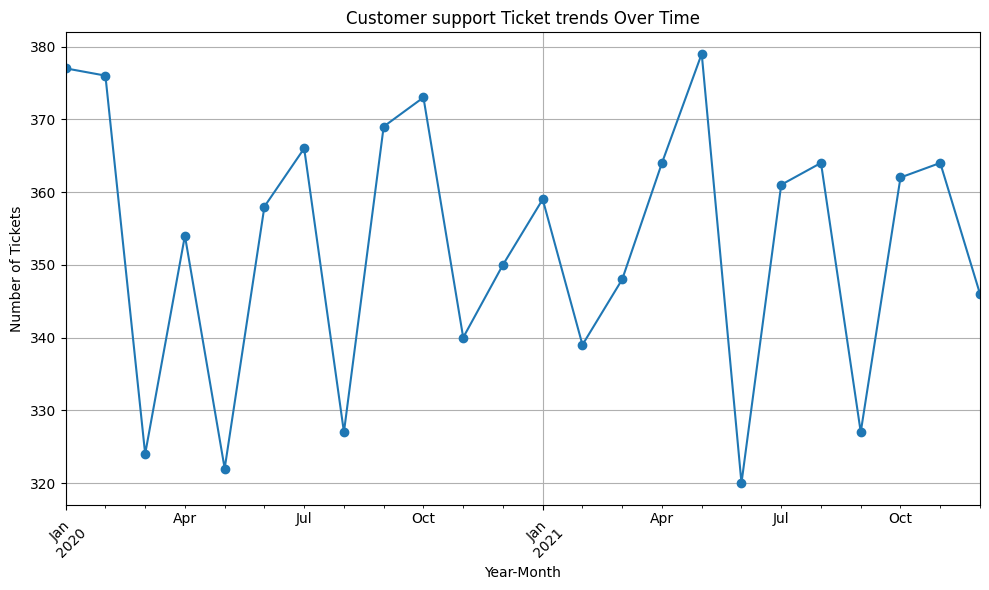

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
ticket_trends.plot(kind='line',marker='o')
plt.title('Customer support Ticket trends Over Time')
plt.xlabel('Year-Month')
plt.ylabel('Number of Tickets')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Observation:**

1.Overall Trend : The number of customer support tickets fluctuates month by month rather than showing a consistent upward or downward trend.This indicates variability in customer issuses across different months.

2.Peak Month : The highest number of tickets is observed in May 2021, reaching approximately 379ticktes.
This suggests a possible spike in customer issues during that period, which may be due to :
Product launch,
Service disruption,
Seasonal demand increase

3.The lowest ticket count appears around june 2021,with approximately 320 tickets
This sharp drop after may  2021 indicates a temporary surge rather thana long-term increasing trend.

4.seasonal pattern: There appears to be moderate recurring flucation across months,but no strong long-term growth pattern between 2020-2021.

This suggests relatively stable support demand with occasional spikes.

**Segment Customers**

In [15]:
#Segment based on ticket types

ticket_type_segmentation=data.groupby('Ticket Type').size()
print("\nsegmentation based on Ticket Types:") 
print(ticket_type_segmentation)


segmentation based on Ticket Types:
Ticket Type
Billing inquiry         1634
Cancellation request    1695
Product inquiry         1641
Refund request          1752
Technical issue         1747
dtype: int64


In [16]:
# Segment based on satisfaction levels 
satisfaction_segmentation=data.groupby('Customer Satisfaction Rating').size()
print("\nsegmentation based on Customer Satisfaction Levels:")
print(satisfaction_segmentation)


segmentation based on Customer Satisfaction Levels:
Customer Satisfaction Rating
1.0    553
2.0    549
3.0    580
4.0    543
5.0    544
dtype: int64


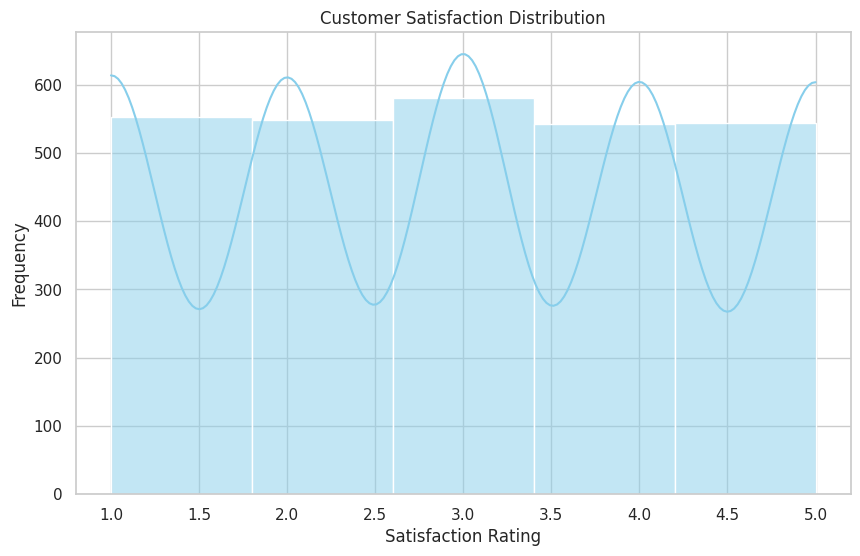

In [24]:
#Set up the plotting aesthetics 
sns.set(style="whitegrid")

#Customer Satisfaction Distribution

plt.figure(figsize=(10,6))
sns.histplot(data['Customer Satisfaction Rating'],bins=5,kde=True,color='skyblue')
plt.title('Customer Satisfaction Distribution')
plt.xlabel('Satisfaction Rating')
plt.ylabel('Frequency')

plt.show()


In [23]:
# check infinity values 
 
np.isinf(data.select_dtypes(include='number')).sum().sum()      # No inf values 

np.int64(0)

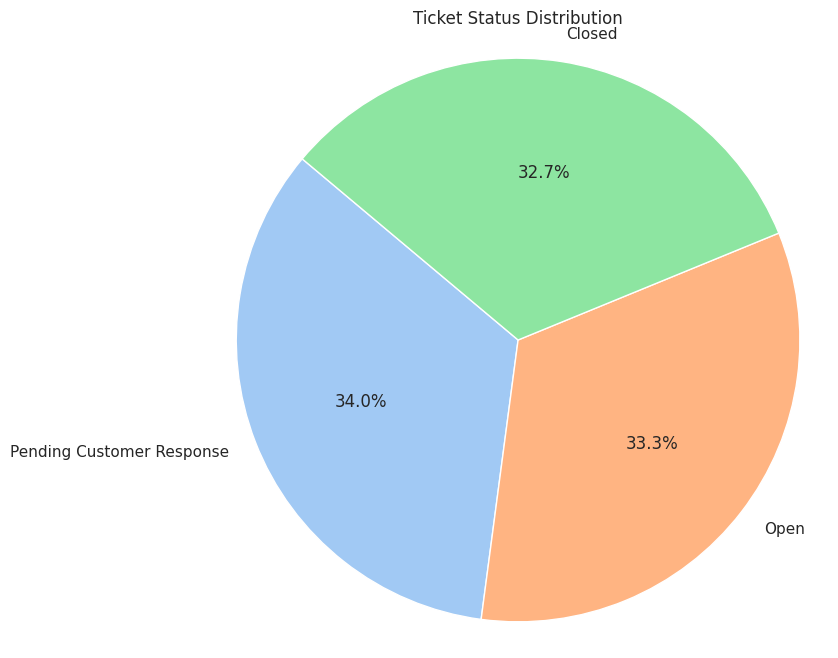

In [25]:
#Ticket Status Distribution
ticket_status_distribution=data['Ticket Status'].value_counts()

plt.figure(figsize=(8,8))
plt.pie(ticket_status_distribution,labels=ticket_status_distribution.index,autopct='%1.1f%%',
        colors=sns.color_palette('pastel'),startangle=140)
plt.title('Ticket Status Distribution')
plt.axis('equal')

plt.show()

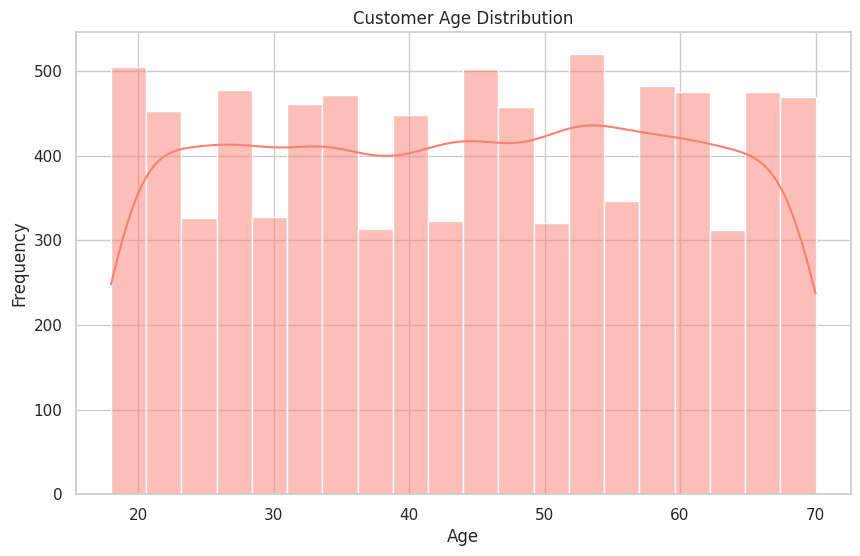

In [28]:
#Customer Age Distribution
plt.figure(figsize=(10,6))
sns.histplot(data['Customer Age'],bins=20,kde=True,color='salmon')
plt.title('Customer Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

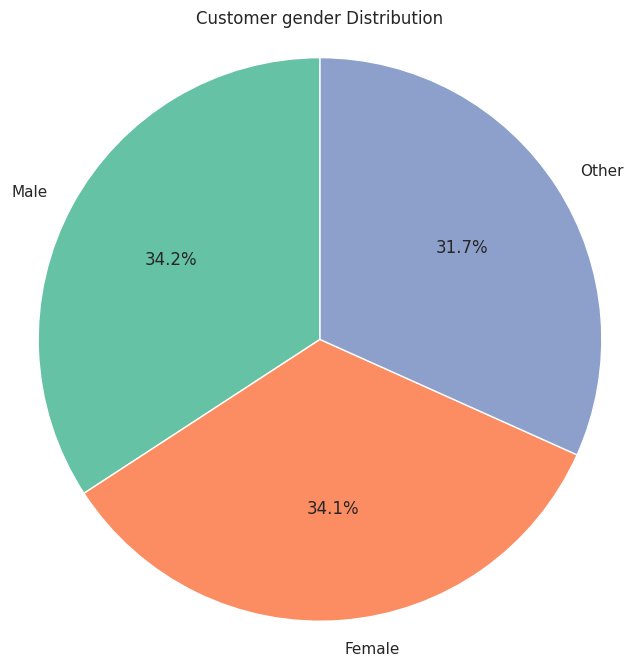

In [29]:
#Customer_gender_distribution
customer_gender_distribution=data['Customer Gender'].value_counts()
plt.figure(figsize=(8,8))
plt.pie(customer_gender_distribution,labels=customer_gender_distribution.index,autopct='%1.1f%%',
        colors=sns.color_palette('Set2'),startangle=90)
plt.title('Customer gender Distribution')
plt.axis('equal')
plt.show()
    

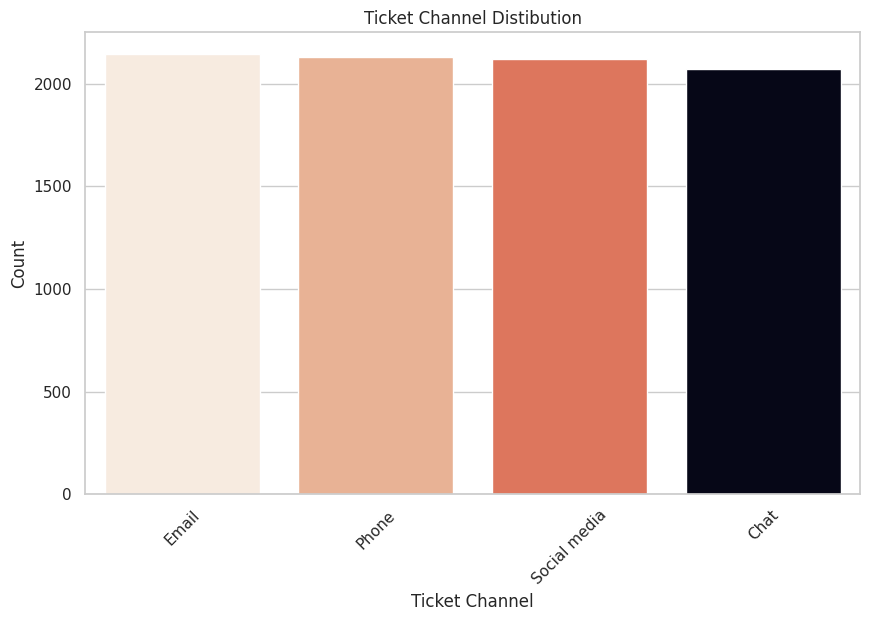

In [30]:
#Ticket Channel Distribtion

plt.figure(figsize=(10,6))
ticket_channel_distribution=data['Ticket Channel'].value_counts()
sns.barplot(x=ticket_channel_distribution.index,y=ticket_channel_distribution,hue=ticket_channel_distribution,
            palette='rocket',legend=False)
plt.title('Ticket Channel Distibution')
plt.xlabel('Ticket Channel')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

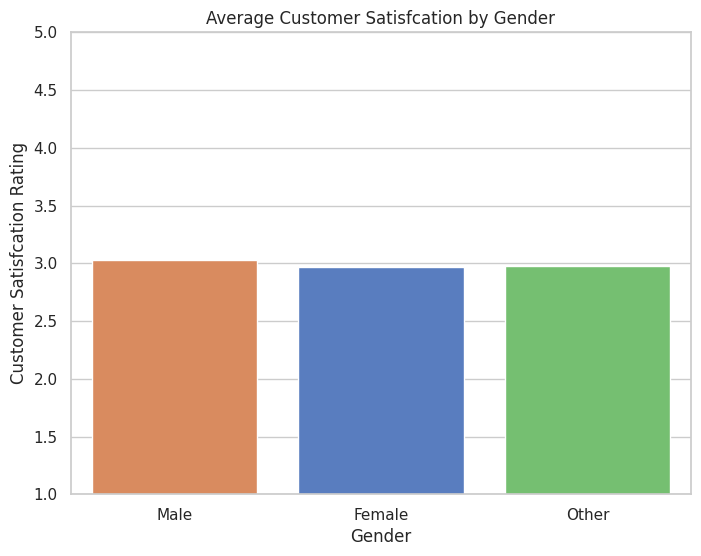

In [31]:
#Average Customer Satisfaction by Gender(Bar Plot)

average_satisfaction=data.groupby('Customer Gender')['Customer Satisfaction Rating'].mean().reset_index()

plt.figure(figsize=(8,6))
sns.barplot(x='Customer Gender',y='Customer Satisfaction Rating',hue='Customer Gender',data=average_satisfaction,palette='muted',order=['Male','Female','Other'],legend=False)
plt.title('Average Customer Satisfcation by Gender')
plt.xlabel('Gender')
plt.ylabel('Customer Satisfcation Rating')
plt.ylim(1,5)         #adjusty-yaxis 

plt.show()

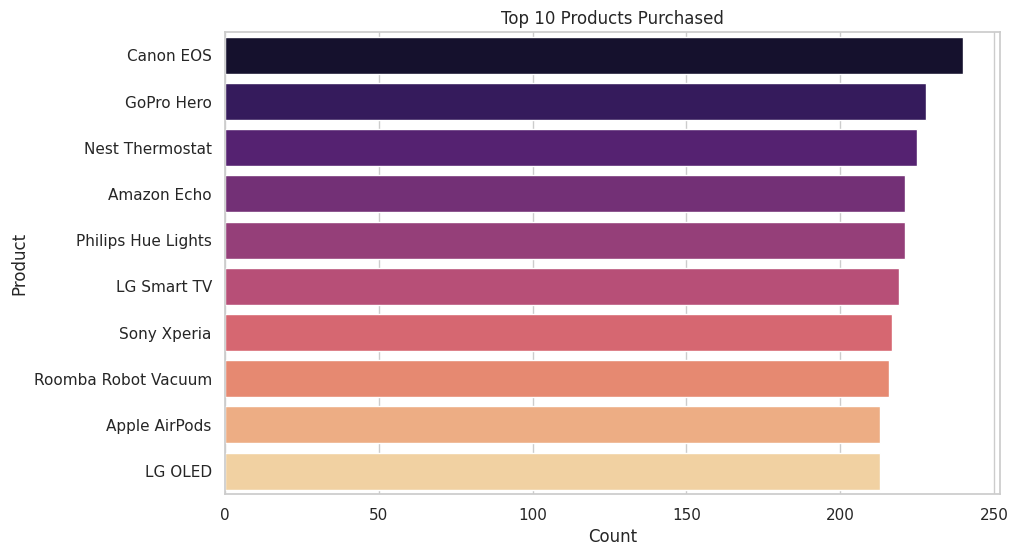

In [32]:
#Product Purchased Distribution
plt.figure(figsize=(10,6))

product_purchased_distribution=data['Product Purchased'].value_counts().head(10)

sns.barplot(y=product_purchased_distribution.index,x=product_purchased_distribution.values,
            hue=product_purchased_distribution.index,palette='magma',legend=False)

plt.title('Top 10 Products Purchased')
plt.xlabel('Count')
plt.ylabel('Product')

plt.show()


**Observation:**
The bar chart shows top 10 most purchased products by customers. Some products have significantly higher purchase counts,indicating stronger customer preference.These products may represent the company's most popular items and could be priortized for marketing strategies and inventory management.

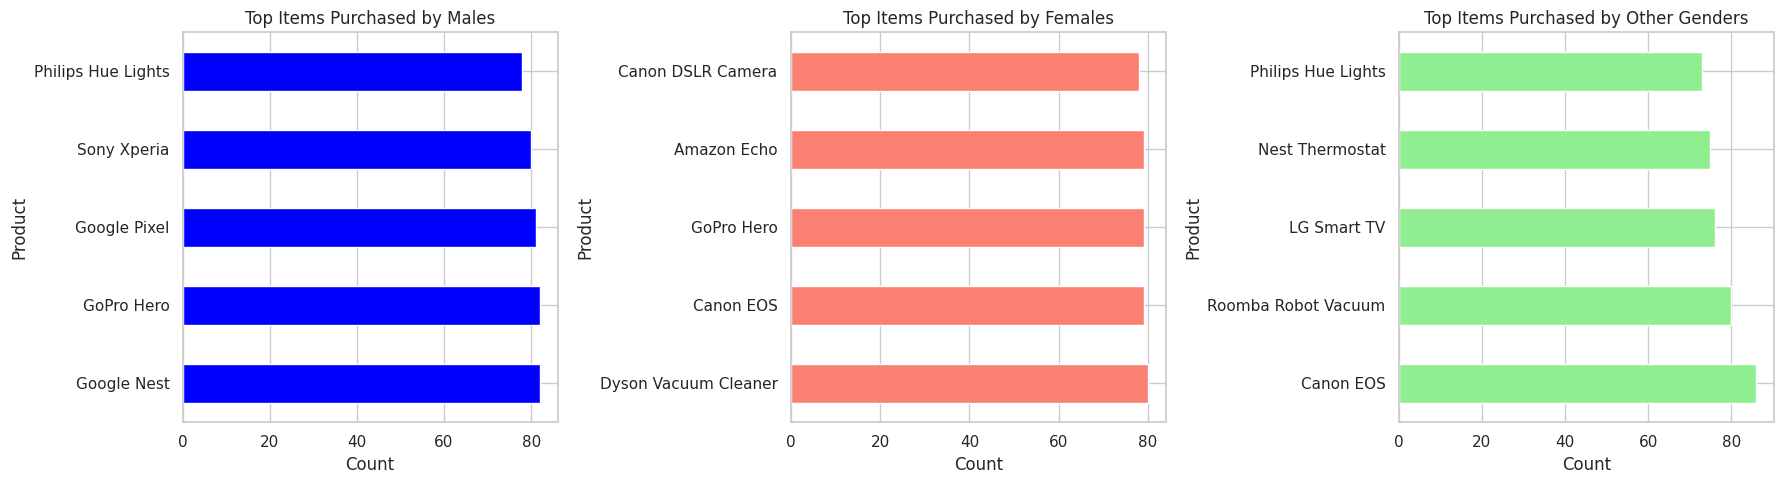

In [33]:
#Top Items purchased by Gender(Horizontal Bar Chart)

plt.figure(figsize=(18,5))

#Top items purchased by Males
plt.subplot(1,3,1)
top_items_male=data[data['Customer Gender']=='Male']['Product Purchased'].value_counts().head(5)
top_items_male.plot(kind='barh',color='blue')
plt.title('Top Items Purchased by Males')
plt.xlabel('Count')
plt.ylabel('Product')

#Top Items purchased by Females
plt.subplot(1,3,2)
top_items_females=data[data['Customer Gender']=='Female']['Product Purchased'].value_counts().head(5)
top_items_females.plot(kind='barh',color='salmon')
plt.title('Top Items Purchased by Females')
plt.xlabel('Count')
plt.ylabel('Product')

#Top Items Purchased by other Gender
plt.subplot(1,3,3)
top_items_other=data[data['Customer Gender']=='Other']['Product Purchased'].value_counts().head(5)
top_items_other.plot(kind='barh',color='lightgreen')
plt.title('Top Items Purchased by Other Genders')
plt.xlabel('Count')
plt.ylabel('Product')

plt.tight_layout()
plt.show()

**Observation :** 

Male and Female customers purchase different products,indicating variation in product preference by gender.
Some Products appear frequently in multiple gender categories ,showing popular items across all customers.
The "Other" gender Category has fewer purchases compared to male and female customers.

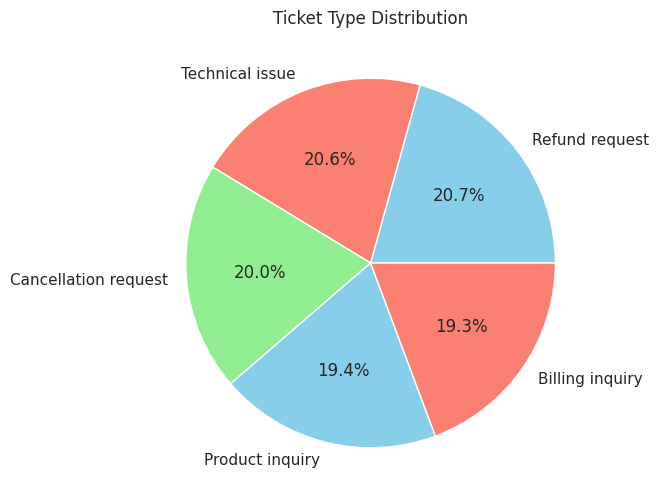

In [34]:
# Count Ticket types 
ticket_type_distribution=data['Ticket Type'].value_counts()

#plot
plt.figure(figsize=(8,6))
ticket_type_distribution.plot(kind='pie',autopct='%1.1f%%',colors=['skyblue','salmon','lightgreen'])
plt.title('Ticket Type Distribution')
plt.ylabel('')
plt.show()

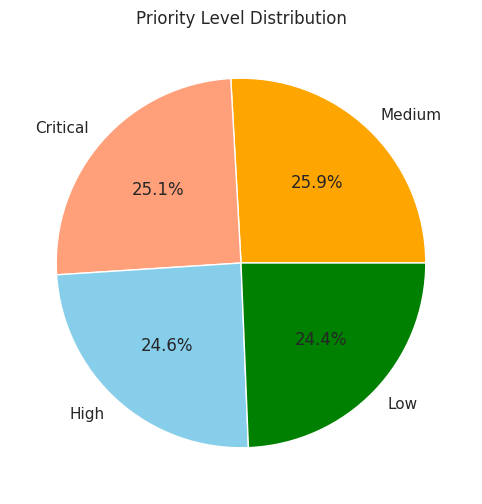

In [44]:
#count ticket priorities
priority_distribution=data['Ticket Priority'].value_counts()

#plot
plt.figure(figsize=(8,6))
priority_distribution.plot(kind='pie',autopct='%1.1f%%',colors=['Orange','lightsalmon','skyblue','green'])
plt.title('Priority Level Distribution')

plt.ylabel('')
plt.show()

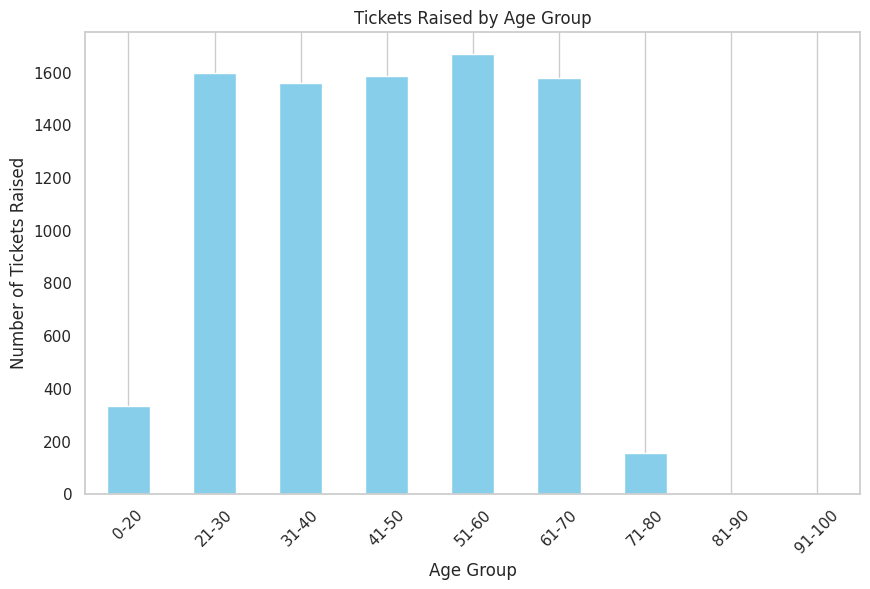

In [56]:
#Define Age groups
bins=[0,20,30,40,50,60,70,80,90,100]
labels=['0-20','21-30','31-40','41-50','51-60','61-70','71-80','81-90','91-100']

# Categorize customers into age groups
data['Age Group']=pd.cut(data['Customer Age'],bins=bins,labels=labels,right=False)

#Calculate number of tickets raised by each age group
tickets_by_age_group=data.groupby('Age Group',observed=False).size()

#plot
plt.figure(figsize=(10,6))
tickets_by_age_group.plot(kind='bar',color='skyblue')
plt.title('Tickets Raised by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Number of Tickets Raised')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.show()

Observation :
Tickets raised by age-group are above among 51-60yrs age and 71-80 age group has less tickets raised. 


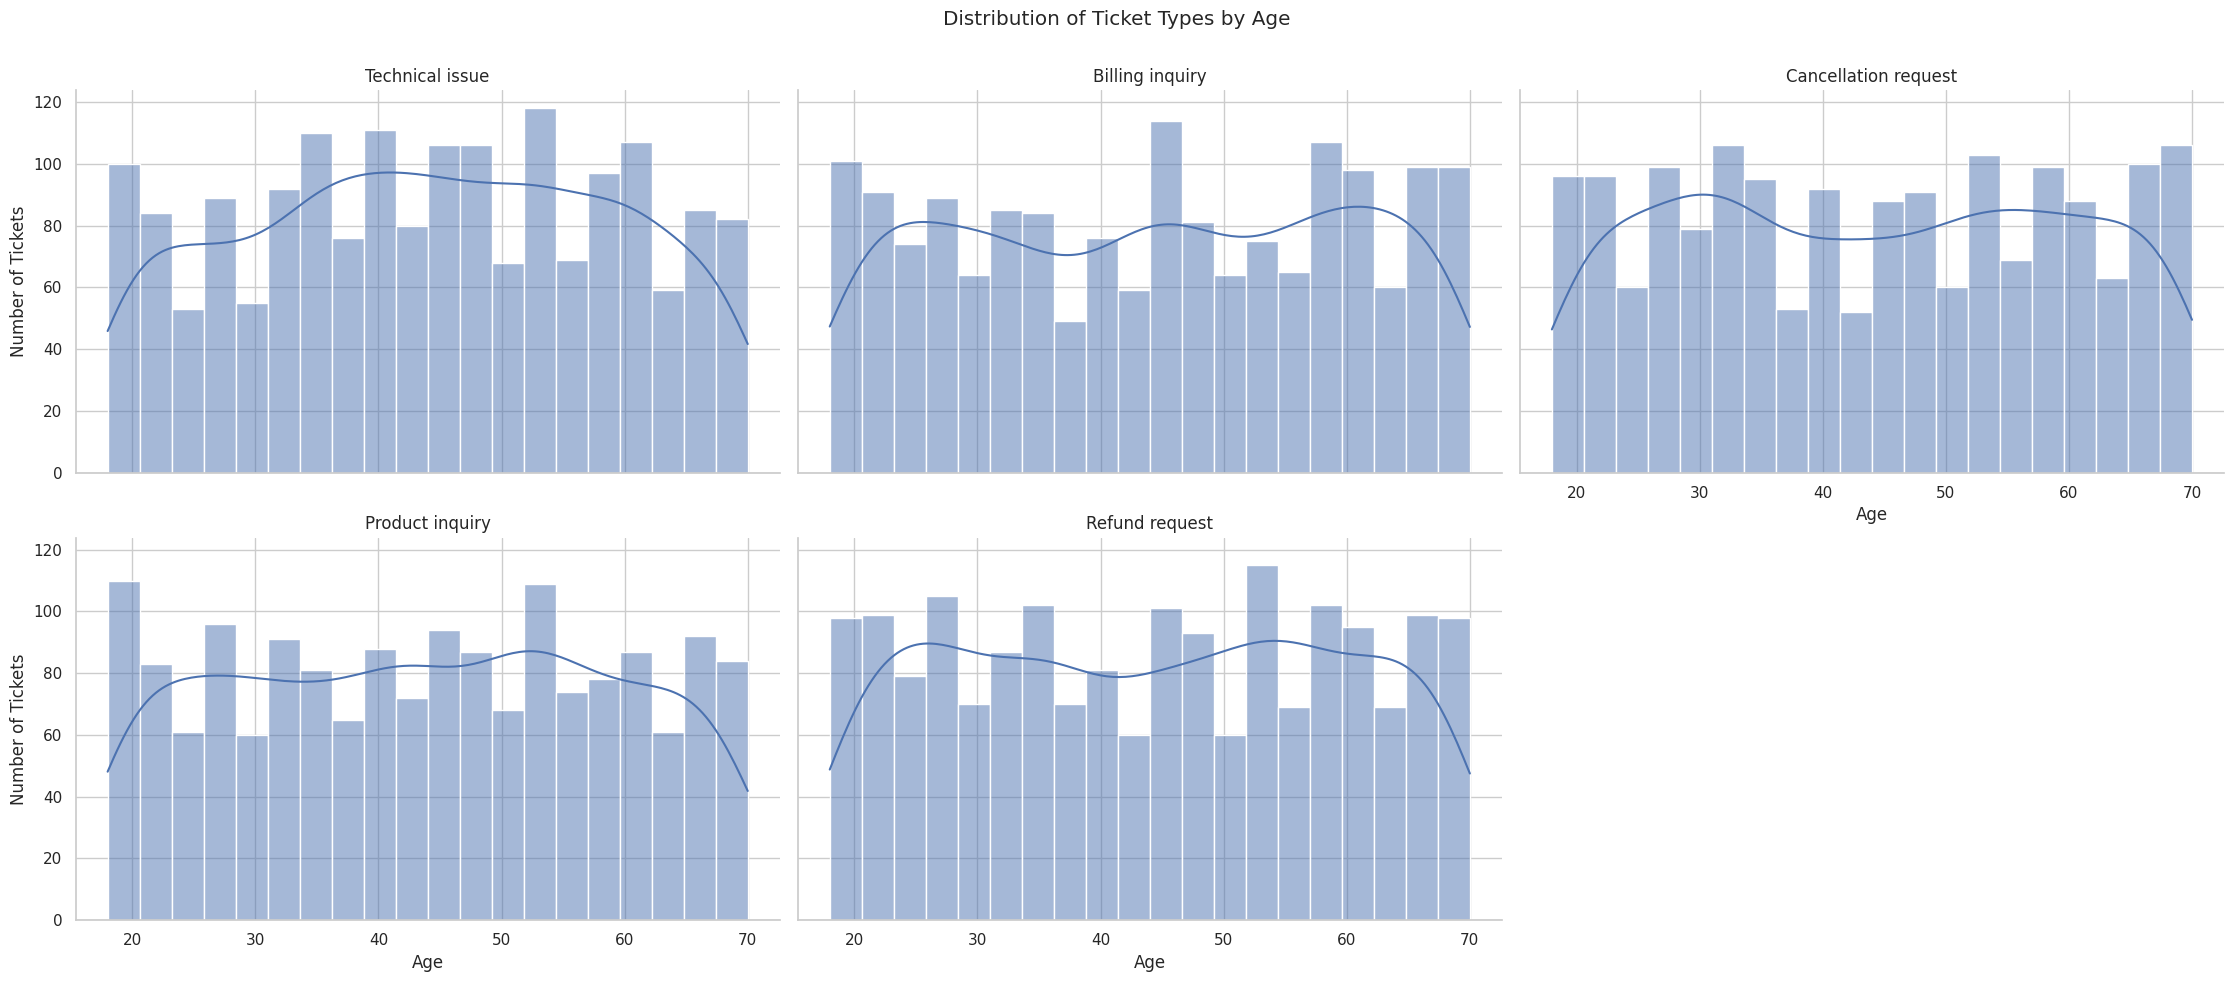

In [60]:
#Create a facet grid for each tickettype
g=sns.FacetGrid(data,col='Ticket Type',col_wrap=3,height=5,aspect=1.5)
g.map(sns.histplot,'Customer Age',bins=20,kde=True)

#Set titles and labels
g.set_titles('{col_name}')
g.set_axis_labels('Age','Number of Tickets')

# Adjust layout
plt.subplots_adjust(top=0.9)
g.fig.suptitle('Distribution of Ticket Types by Age')

#show plot
plt.show()